<a href="https://colab.research.google.com/github/FareyaHossain/unsupervised-music-generation/blob/main/22301679_Fareya_Hossain_523.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Import Libraries

In [ ]:
!pip install pretty_midi
import numpy as np
import os
import random
import shutil
import zipfile
import pretty_midi
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 47.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 3.7 MB/s eta 0:00:00
  Created wheel for pretty_midi: filename=pretty_midi-0.2.11-py3-none-any.whl size=5595886 sha256=dec38e35f657d8b01847922398be0cf425c02d9071907beb252667e99323bf20
  Stored in directory: /root/.cache/pip/wheels/f4/ad/93/a7042fe12668827574927ade9deec7f29aad2a1001b1501882
Successfully built pretty_midi


UPLOAD DATASET

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving maestro-v3.0.0-midi.zip to maestro-v3.0.0-midi.zip


In [ ]:
with zipfile.ZipFile("maestro-v3.0.0-midi.zip", 'r') as zip_ref:
    zip_ref.extractall("data/raw_midi")

print("Unzipped done")

Unzipped done


CHECK FILES

In [ ]:
print(os.listdir("data"))
print(os.listdir("data/raw_midi")[:10])

['raw_midi']
['maestro-v3.0.0']


COLLECT MIDI FILE PATHS

In [ ]:
midi_files = []

for root, dirs, files in os.walk("data/raw_midi"):
    for file in files:
        if file.endswith(".mid") or file.endswith(".midi"):
            midi_files.append(os.path.join(root, file))

print("Total MIDI files:", len(midi_files))
print("Sample:", midi_files[:5])



Total MIDI files: 1276
Sample: ['data/raw_midi/maestro-v3.0.0/2008/MIDI-Unprocessed_02_R1_2008_01-05_ORIG_MID--AUDIO_02_R1_2008_wav--2.midi', 'data/raw_midi/maestro-v3.0.0/2008/MIDI-Unprocessed_17_R2_2008_01-04_ORIG_MID--AUDIO_17_R2_2008_wav--1.midi', 'data/raw_midi/maestro-v3.0.0/2008/MIDI-Unprocessed_07_R2_2008_01-05_ORIG_MID--AUDIO_07_R2_2008_wav--3.midi', 'data/raw_midi/maestro-v3.0.0/2008/MIDI-Unprocessed_02_R2_2008_01-05_ORIG_MID--AUDIO_02_R2_2008_wav--1.midi', 'data/raw_midi/maestro-v3.0.0/2008/MIDI-Unprocessed_15_R2_2008_01-04_ORIG_MID--AUDIO_15_R2_2008_wav--4.midi']


CREATE SMALL DATASET

In [ ]:
target_dir = "data/small_dataset"
os.makedirs(target_dir, exist_ok=True)

sample = random.sample(midi_files, 80)

for path in sample:
    shutil.copy(path, target_dir)

print("Small Dataset :", len(sample))

Small Dataset : 80


MIDI → PIANO ROLL FUNCTION

In [ ]:
def midi_to_piano_roll(path, fs=16):
    midi = pretty_midi.PrettyMIDI(path)
    roll = midi.get_piano_roll(fs=fs).T
    roll[roll > 0] = 1
    return roll

PREPROCESSING

In [ ]:
data = []
window = 100

for file in os.listdir("data/small_dataset"):
    path = os.path.join("data/small_dataset", file)

    try:
        roll = midi_to_piano_roll(path)
        for i in range(0, len(roll) - window, window):
            chunk = roll[i:i+window]

            if chunk.shape == (100,128):
                data.append(chunk)



    except:
        continue

data = np.array([x for x in data if np.sum(x) > 10])

print("Final Dataset shape:", data.shape)

Final Dataset shape: (8546, 100, 128)


In [ ]:
import numpy as np
data = np.array([x for x in data if x.shape == (100,128)])

print("Clean dataset:", data.shape)

Clean dataset: (8546, 100, 128)


In [ ]:
print("Non-zero values:", np.sum(data[0]))

Non-zero values: 295.0


VISUALIZE DATA

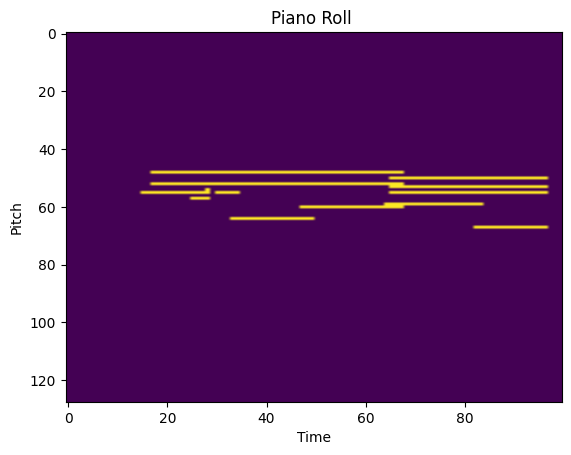

In [ ]:

plt.imshow(data[0].T, aspect='auto')
plt.title("Piano Roll ")
plt.xlabel("Time")
plt.ylabel("Pitch")
plt.show()

LISTEN SAMPLE

In [ ]:
def create_midi(pred, filename):
    midi = pretty_midi.PrettyMIDI()
    instrument = pretty_midi.Instrument(program=0)

    for t, frame in enumerate(pred):
        for note in range(128):
            if frame[note] > 0.3:
                note_obj = pretty_midi.Note(
                    velocity=100,
                    pitch=note,
                    start=t * 0.1,
                    end=(t + 1) * 0.1
                )
                instrument.notes.append(note_obj)

    midi.instruments.append(instrument)
    midi.write(filename)

create_midi(data[0], "original.mid")

from google.colab import files
files.download("original.mid")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

TRAIN VAL  SPLIT

In [ ]:
X_train, X_val = train_test_split(data, test_size=0.2, random_state=42)

X_train = X_train.astype("float32")
X_val = X_val.astype("float32")

print("Train:", X_train.shape)
print("Val:", X_val.shape)

Train: (6836, 100, 128)
Val: (1710, 100, 128)


TASK 1: LSTM AUTOENCODER

In [ ]:
from tensorflow.keras import layers, Model

inputs = layers.Input(shape=(100,128))

x = layers.LSTM(128)(inputs)
x = layers.RepeatVector(100)(x)
x = layers.LSTM(128, return_sequences=True)(x)

outputs = layers.TimeDistributed(
    layers.Dense(128, activation="sigmoid")
)(x)

ae = Model(inputs, outputs)
ae.compile(optimizer="adam", loss="binary_crossentropy")

TRAIN AE

In [ ]:
history_ae = ae.fit(
    X_train, X_train,
    validation_data=(X_val, X_val),
    epochs=5,
    batch_size=16
)

Epoch 1/5
428/428 ━━━━━━━━━━━━━━━━━━━━ 111s 239ms/step - loss: 0.1517 - val_loss: 0.1316
Epoch 2/5
428/428 ━━━━━━━━━━━━━━━━━━━━ 138s 229ms/step - loss: 0.1350 - val_loss: 0.1315
Epoch 3/5
428/428 ━━━━━━━━━━━━━━━━━━━━ 97s 227ms/step - loss: 0.1311 - val_loss: 0.1231
Epoch 4/5
428/428 ━━━━━━━━━━━━━━━━━━━━ 143s 229ms/step - loss: 0.1244 - val_loss: 0.1214
Epoch 5/5
428/428 ━━━━━━━━━━━━━━━━━━━━ 98s 228ms/step - loss: 0.1258 - val_loss: 0.1215


Reconstruction Loss Curve

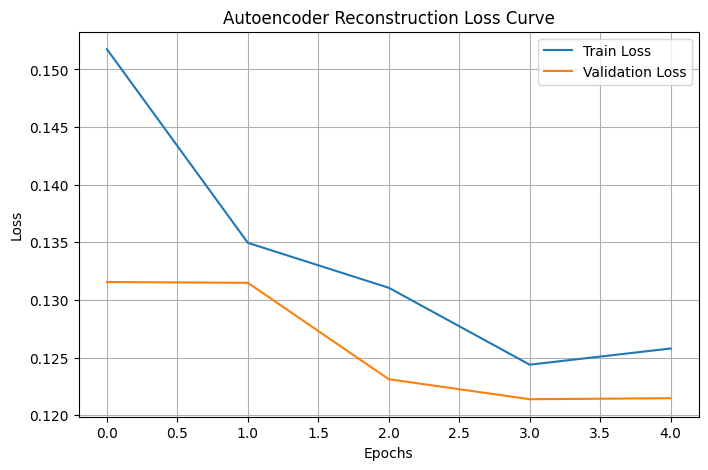

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))


plt.plot(history_ae.history['loss'], label='Train Loss')


if 'val_loss' in history_ae.history:
    plt.plot(history_ae.history['val_loss'], label='Validation Loss')

plt.title("Autoencoder Reconstruction Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()









GENERATE 5 MIDI

In [ ]:
for i in range(5):
    sample = X_val[i]
    recon = ae.predict(sample.reshape(1,100,128))[0]
    create_midi(recon, f"ae_{i+1}.mid")

print("5 AE MIDI generated")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
5 AE MIDI generated


In [ ]:
for i in range(1,6):
    files.download(f"ae_{i}.mid")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

TASK 2: VARIATIONAL AUTOENCODER.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model

timesteps = 100
features = 128
latent_dim = 64

SAMPLING LAYER

In [ ]:
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]

        epsilon = tf.random.normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

ENCODER

In [ ]:
inputs = layers.Input(shape=(timesteps, features))

x = layers.LSTM(128)(inputs)
x = layers.Dense(128, activation="relu")(x)

z_mean = layers.Dense(latent_dim)(x)
z_log_var = layers.Dense(latent_dim)(x)

z = Sampling()([z_mean, z_log_var])

encoder = Model(inputs, [z_mean, z_log_var, z])
encoder.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 100, 128)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 128)       │    131,584 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 128)       │     16,512 │ lstm_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      8,256 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 64)        │      8,256 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sampling (Sampling) │ (None, 64)        │          0 │ dense_2[0][0],    │
│                     │                   │            │ dense_3[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 164,608 (643.00 KB)

 Trainable params: 164,608 (643.00 KB)

 Non-trainable params: 0 (0.00 B)

DECODER

In [ ]:
latent_inputs = layers.Input(shape=(latent_dim,))

x = layers.Dense(128, activation="relu")(latent_inputs)
x = layers.RepeatVector(timesteps)(x)

x = layers.LSTM(128, return_sequences=True)(x)

outputs = layers.TimeDistributed(
    layers.Dense(features, activation="sigmoid")
)(x)

decoder = Model(latent_inputs, outputs)
decoder.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ repeat_vector_1 (RepeatVector)  │ (None, 100, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 100, 128)       │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 100, 128)       │        16,512 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 156,416 (611.00 KB)

 Trainable params: 156,416 (611.00 KB)

 Non-trainable params: 0 (0.00 B)

VAE MODEL

In [ ]:
from tensorflow import keras
import tensorflow as tf
from tensorflow.keras import layers, Model

class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(
            name="reconstruction_loss"
        )
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        reconstruction = self.decoder(z)
        return reconstruction

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            reconstruction_loss = tf.reduce_mean(
                keras.losses.binary_crossentropy(data, reconstruction)
            )
            kl_loss = -0.5 * (1 + z_log_var - keras.ops.square(z_mean) - keras.ops.exp(z_log_var))
            kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
            total_loss = reconstruction_loss + 0.001 * kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }


vae = VAE(encoder, decoder)
vae.compile(optimizer=keras.optimizers.Adam(), loss='binary_crossentropy')

TRAIN

In [ ]:
history_vae = vae.fit(X_train, epochs=5, batch_size=16)

Epoch 1/5
428/428 ━━━━━━━━━━━━━━━━━━━━ 99s 208ms/step - kl_loss: 0.1358 - loss: 0.1528 - reconstruction_loss: 0.1526
Epoch 2/5
428/428 ━━━━━━━━━━━━━━━━━━━━ 142s 208ms/step - kl_loss: 0.0075 - loss: 0.1351 - reconstruction_loss: 0.1350
Epoch 3/5
428/428 ━━━━━━━━━━━━━━━━━━━━ 88s 206ms/step - kl_loss: 0.0017 - loss: 0.1350 - reconstruction_loss: 0.1350
Epoch 4/5
428/428 ━━━━━━━━━━━━━━━━━━━━ 143s 208ms/step - kl_loss: 8.2278e-04 - loss: 0.1348 - reconstruction_loss: 0.1348
Epoch 5/5
428/428 ━━━━━━━━━━━━━━━━━━━━ 87s 204ms/step - kl_loss: 0.0026 - loss: 0.1348 - reconstruction_loss: 0.1348


LOSS CURVE

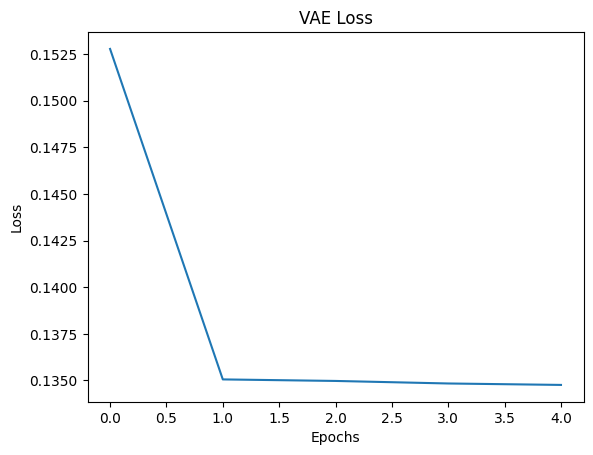

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history_vae.history["loss"])
plt.title("VAE Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

MUSIC GENERATION

In [ ]:
import numpy as np

def generate_music(decoder):
    z = np.random.normal(size=(1, latent_dim))
    return decoder.predict(z)[0]

MIDI

In [ ]:
import pretty_midi

def create_midi(pred, filename):
    midi = pretty_midi.PrettyMIDI()
    instrument = pretty_midi.Instrument(program=0)

    for t, frame in enumerate(pred):
        for note in range(128):
            if frame[note] > 0.5:
                note_obj = pretty_midi.Note(
                    velocity=100,
                    pitch=note,
                    start=t * 0.1,
                    end=(t + 1) * 0.1
                )
                instrument.notes.append(note_obj)

    midi.instruments.append(instrument)
    midi.write(filename)

GENERATE 8 SAMPLES

In [ ]:
for i in range(8):
    pred = generate_music(decoder)
    create_midi(pred, f"vae_{i+1}.mid")

print("8 MIDI files generated")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
8 MIDI files generated


In [ ]:
for i in range(1,9):
    files.download(f"vae_{i}.mid")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

LATENT INTERPOLATION

In [ ]:
import numpy as np

def interpolate(z1, z2, steps=10):
    results = []

    for i in range(steps):
        alpha = i / (steps - 1)
        z = (1 - alpha) * z1 + alpha * z2
        results.append(decoder.predict(z)[0])

    return results

In [ ]:
z1 = np.random.normal(size=(1, latent_dim))
z2 = np.random.normal(size=(1, latent_dim))

outputs = interpolate(z1, z2)

for i, out in enumerate(outputs):
    create_midi(out, f"interp_{i+1}.mid")

print("Interpolation done")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
Interpolation done


In [ ]:
for i in range(1, 11):
    files.download(f"interp_{i}.mid")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Metrics vs Task 1 comparison

PITCH HISTOGRAM

In [ ]:
import numpy as np

def pitch_histogram(sample):

    pitch_counts = np.sum(sample, axis=0)


    hist = np.zeros(12)

    for i in range(128):
        hist[i % 12] += pitch_counts[i]

    hist = hist / (np.sum(hist) + 1e-8)
    return hist

HISTOGRAM DIFFERENCE

In [ ]:
def histogram_distance(p, q):
    return np.sum(np.abs(p - q))

RHYTHM DIVERSITY

In [ ]:
def rhythm_diversity(sample):
    active_counts = np.sum(sample, axis=1)

    unique_patterns = len(set(active_counts))
    total = len(active_counts)

    return unique_patterns / total

REPETITION RATIO

In [ ]:
def repetition_ratio(sample):
    patterns = []

    for i in range(len(sample) - 8):
        patterns.append(tuple(sample[i:i+8].flatten()))

    total = len(patterns)
    unique = len(set(patterns))

    if total == 0:
        return 0

    return 1 - (unique / total)

GENERATE SAMPLES FROM BOTH MODELS

In [ ]:

ae_outputs = []
for i in range(10):
    recon = ae.predict(X_val[i].reshape(1,100,128))[0]
    ae_outputs.append(recon)


vae_outputs = []
for i in range(10):
    pred = generate_music(decoder)
    vae_outputs.append(pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step


COMPUTE METRICS

In [ ]:
def evaluate(outputs, reference):
    hist_scores = []
    rhythm_scores = []
    repetition_scores = []

    ref_hist = pitch_histogram(reference)

    for sample in outputs:
        hist = pitch_histogram(sample)

        hist_scores.append(histogram_distance(hist, ref_hist))
        rhythm_scores.append(rhythm_diversity(sample))
        repetition_scores.append(repetition_ratio(sample))

    return (
        np.mean(hist_scores),
        np.mean(rhythm_scores),
        np.mean(repetition_scores)
    )

COMPARISON

In [ ]:
reference = X_val[0]

ae_metrics = evaluate(ae_outputs, reference)
vae_metrics = evaluate(vae_outputs, reference)

In [ ]:
import numpy as np


ae_scores = [
    [2,3,2,3,2],
    [3,3,2,2,3]
]

vae_scores = [
    [3,4,3,4,3],
    [4,4,3,4,4]
]

def average_score(scores):
    return np.mean(scores)

ae_human = average_score(ae_scores)
vae_human = average_score(vae_scores)

print("AE Human Score:", ae_human)
print("VAE Human Score:", vae_human)

AE Human Score: 2.5
VAE Human Score: 3.6


In [ ]:
print("=== PERFORMANCE COMPARISON ===\n")

print("Autoencoder (Task 1):")
print("Pitch Distance:", ae_metrics[0])
print("Rhythm Diversity:", ae_metrics[1])
print("Repetition Ratio:", ae_metrics[2])
print("Human Score:", ae_human)

print("\nVAE (Task 2):")
print("Pitch Distance:", vae_metrics[0])
print("Rhythm Diversity:", vae_metrics[1])
print("Repetition Ratio:", vae_metrics[2])
print("Human Score:", vae_human)

=== PERFORMANCE COMPARISON ===

Autoencoder (Task 1):
Pitch Distance: 0.7189777366500774
Rhythm Diversity: 0.5660000000000001
Repetition Ratio: 0.03152173913043478
Human Score: 2.5

VAE (Task 2):
Pitch Distance: 0.7129596589763535
Rhythm Diversity: 0.14700000000000005
Repetition Ratio: 0.5369565217391304
Human Score: 3.6


In [ ]:
import pandas as pd

df = pd.DataFrame({
    "Model": ["Autoencoder (Task 1)", "VAE (Task 2)"],
    "Pitch Distance": [ae_metrics[0], vae_metrics[0]],
    "Rhythm Diversity": [ae_metrics[1], vae_metrics[1]],
    "Repetition Ratio": [ae_metrics[2], vae_metrics[2]],
    "Human Score": [ae_human, vae_human]
})


df = df.round(4)

print("\n=== PERFORMANCE COMPARISON TABLE ===\n")
print(df.to_string(index=False))


=== PERFORMANCE COMPARISON TABLE ===

               Model  Pitch Distance  Rhythm Diversity  Repetition Ratio  Human Score
Autoencoder (Task 1)           0.719             0.566            0.0315          2.5
        VAE (Task 2)           0.713             0.147            0.5370          3.6


TASK 3: TRANSFORMER

PREPARE SEQUENCE DATA

In [ ]:
import pretty_midi
import numpy as np
import os

def midi_to_piano_roll(file_path, fs=16):
    midi = pretty_midi.PrettyMIDI(file_path)
    roll = midi.get_piano_roll(fs=fs).T
    roll[roll > 0] = 1
    return roll

data = []

for file in os.listdir("data/small_dataset"):
    path = os.path.join("data/small_dataset", file)
    try:
        roll = midi_to_piano_roll(path)
        if len(roll) >= 100:
            roll = roll[:100]
            data.append(roll)
    except:
        continue

data = np.array(data)

print("Dataset:", data.shape)

Dataset: (80, 100, 128)


CREATE SEQUENCES

In [ ]:
seq_length = 30

X_seq = []
y_seq = []

for sample in data:
    for i in range(len(sample) - seq_length):
        X_seq.append(sample[i:i+seq_length])
        y_seq.append(sample[i+1:i+seq_length+1])

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

print("X:", X_seq.shape)
print("y:", y_seq.shape)

X: (5600, 30, 128)
y: (5600, 30, 128)


TRAIN/VAL SPLIT

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_seq, y_seq, test_size=0.2, random_state=42
)

X_train = X_train.astype("float32")
X_val = X_val.astype("float32")
y_train = y_train.astype("float32")
y_val = y_val.astype("float32")

POSITIONAL ENCODING

In [ ]:
import tensorflow as tf

def positional_encoding(length, depth):
    pos = np.arange(length)[:, np.newaxis]
    i = np.arange(depth)[np.newaxis, :]

    angle_rates = 1 / np.power(10000, (2 * (i//2)) / np.float32(depth))
    angle_rads = pos * angle_rates

    angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
    angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])

    return tf.cast(angle_rads, dtype=tf.float32)

TRANSFORMER MODEL

In [ ]:
from tensorflow.keras import layers, Model

inputs = layers.Input(shape=(seq_length, 128))

x = inputs + positional_encoding(seq_length, 128)


attn = layers.MultiHeadAttention(num_heads=4, key_dim=32)(x, x)
x = layers.Add()([x, attn])
x = layers.LayerNormalization()(x)

ff = layers.Dense(256, activation="relu")(x)
ff = layers.Dense(128)(ff)

x = layers.Add()([x, ff])
x = layers.LayerNormalization()(x)

outputs = layers.Dense(128, activation="sigmoid")(x)

transformer = Model(inputs, outputs)

transformer.compile(
    optimizer="adam",
    loss="binary_crossentropy"
)

transformer.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 30, 128)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 30, 128)   │          0 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 30, 128)   │     66,048 │ add[0][0],        │
│ (MultiHeadAttentio… │                   │            │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 30, 128)   │          0 │ add[0][0],        │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 30, 128)   │        256 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 30, 256)   │     33,024 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 30, 128)   │     32,896 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 30, 128)   │          0 │ layer_normalizat… │
│                     │                   │            │ dense_7[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 30, 128)   │        256 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 30, 128)   │     16,512 │ layer_normalizat… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 148,992 (582.00 KB)

 Trainable params: 148,992 (582.00 KB)

 Non-trainable params: 0 (0.00 B)

TRAIN

In [ ]:
history = transformer.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=32
)

Epoch 1/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 14s 78ms/step - loss: 0.1400 - val_loss: 0.0962
Epoch 2/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 74ms/step - loss: 0.0649 - val_loss: 0.0363
Epoch 3/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 10s 69ms/step - loss: 0.0275 - val_loss: 0.0209
Epoch 4/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 12s 83ms/step - loss: 0.0176 - val_loss: 0.0137
Epoch 5/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 11s 78ms/step - loss: 0.0111 - val_loss: 0.0082


LOSS GRAPH

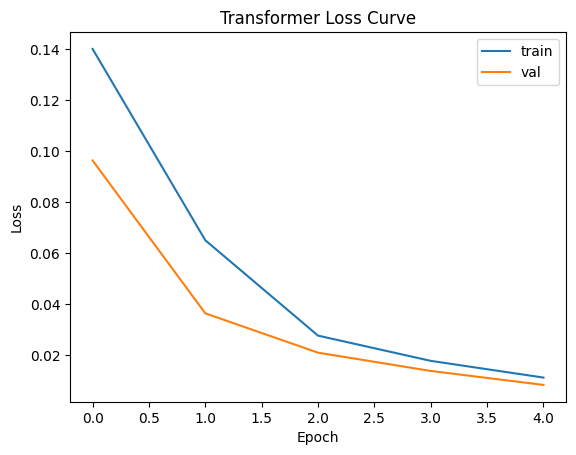

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title("Transformer Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

GENERATE FUNCTION

In [ ]:
def generate_music(model, seed, steps=70):
    generated = seed.copy()

    for _ in range(steps):
        pred = model.predict(generated[np.newaxis, ...], verbose=0)[0]
        next_step = pred[-1]

        generated = np.vstack([generated, next_step])
        generated = generated[-seq_length:]

    return generated

MIDI FUNCTION

In [ ]:
import pretty_midi

def create_midi(pred, filename):
    midi = pretty_midi.PrettyMIDI()
    instrument = pretty_midi.Instrument(program=0)

    for t, frame in enumerate(pred):
        for note in range(128):
            if frame[note] > 0.5:
                note_obj = pretty_midi.Note(
                    velocity=100,
                    pitch=note,
                    start=t * 0.1,
                    end=(t + 1) * 0.1
                )
                instrument.notes.append(note_obj)

    midi.instruments.append(instrument)
    midi.write(filename)

GENERATE 10 MIDI FILES

In [ ]:
import os
os.makedirs("transformer_outputs", exist_ok=True)

for i in range(10):
    seed = X_val[i]
    gen = generate_music(transformer, seed)

    create_midi(gen, f"transformer_outputs/t3_{i+1}.mid")

print("10 MIDI files generated")

10 MIDI files generated


In [ ]:
for i in range(1,11):
    files.download(f"transformer_outputs/t3_{i}.mid")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

PERPLEXITY

In [ ]:
import numpy as np

loss = np.mean(history.history["loss"])
perplexity = np.exp(loss)
print("Validation Loss:", loss)
print("Perplexity:", perplexity)



Validation Loss: 0.052236932888627054
Perplexity: 1.0536253514399625


BASELINE COMPARISISON


In [ ]:
import numpy as np

def random_generator(num_samples=1):
    return np.random.randint(0, 2, (num_samples, 100, 128)).astype(np.float32)

def train_markov(data):
    transition = np.zeros((128, 128))

    for seq in data:
        for t in range(len(seq)-1):

            curr_notes = np.where(seq[t] > 0)[0]
            next_notes = np.where(seq[t+1] > 0)[0]

            if len(curr_notes) > 0 and len(next_notes) > 0:
                for curr_note in curr_notes:
                    for next_note in next_notes:
                        if 0 <= curr_note < 128 and 0 <= next_note < 128:
                            transition[curr_note][next_note] += 1


    row_sums = transition.sum(axis=1, keepdims=True)
    transition = np.where(row_sums > 0, transition / row_sums, 0) # Avoid division by zero
    return transition

def generate_markov(model, length=100):
    seq = np.zeros((length, 128))


    note = np.random.randint(0, 128)

    for t in range(length):
        seq[t][note] = 1

        if np.sum(model[note]) > 0:
            note = np.random.choice(128, p=model[note])
        else:

            note = np.random.randint(0, 128)

    return seq



real = X_val[0]


seed = real[:seq_length]
transformer_output = generate_music(transformer, seed)


random_output = random_generator(num_samples=1)[0]

markov_model = train_markov(data)
markov_output = generate_markov(markov_model, length=100)

/tmp/ipykernel_21252/1960554022.py:23: RuntimeWarning: invalid value encountered in divide
  transition = np.where(row_sums > 0, transition / row_sums, 0) # Avoid division by zero


Metrics Functions

In [ ]:
def pitch_histogram(roll):
    return np.sum(roll, axis=0)

def pitch_distance(p, q):
    return np.sum(np.abs(p - q))

def rhythm_diversity(roll):
    durations = np.sum(roll, axis=1)
    return len(np.unique(durations)) / len(durations)

def repetition_ratio(roll):
    patterns = [tuple(row) for row in roll]
    return 1 - (len(set(patterns)) / len(patterns))

Compute Metrics

In [ ]:
real_hist = pitch_histogram(real)

def compute_metrics(sample):
    hist = pitch_histogram(sample)
    return [
        pitch_distance(real_hist, hist),
        rhythm_diversity(sample),
        repetition_ratio(sample)
    ]

random_m = compute_metrics(random_output)
markov_m = compute_metrics(markov_output)
transformer_m = compute_metrics(transformer_output)

Human Scores (manually)

In [ ]:
random_score = 1.2
markov_score = 2.3
transformer_score = 4.4

BASELINE TABLE

In [ ]:
import pandas as pd

df = pd.DataFrame({
    "Model": ["Random", "Markov", "Transformer"],
    "Pitch Distance": [
        random_m[0], markov_m[0], transformer_m[0]
    ],
    "Rhythm Diversity": [
        random_m[1], markov_m[1], transformer_m[1]
    ],
    "Repetition Ratio": [
        random_m[2], markov_m[2], transformer_m[2]
    ],
    "Human Score": [
        random_score, markov_score, transformer_score
    ]
})

print("\n=== BASELINE COMPARISON ===\n")
print(df.to_string(index=False))


=== BASELINE COMPARISON ===

      Model  Pitch Distance  Rhythm Diversity  Repetition Ratio  Human Score
     Random     6330.000000              0.28              0.00          1.2
     Markov      177.000000              0.01              0.56          2.3
Transformer       58.885307              1.00              0.00          4.4


In [ ]:
from sklearn.model_selection import train_test_split


ae_X_train, ae_X_val = train_test_split(data, test_size=0.2, random_state=42)

ae_X_train = ae_X_train.astype("float32")
ae_X_val = ae_X_val.astype("float32")

print("AE Train data shape:", ae_X_train.shape)
print("AE Val data shape:", ae_X_val.shape)

AE Train data shape: (64, 100, 128)
AE Val data shape: (16, 100, 128)


In [ ]:
print("\n--- Model Comparison ---")
print("Model\t\tLoss\tPerplexity")


import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow import keras

timesteps = 100
features = 128
latent_dim = 64

class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]

        epsilon = tf.random.normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

inputs_vae_temp = layers.Input(shape=(timesteps, features))
x_vae_temp = layers.LSTM(128)(inputs_vae_temp)
x_vae_temp = layers.Dense(128, activation="relu")(x_vae_temp)

z_mean_temp = layers.Dense(latent_dim)(x_vae_temp)
z_log_var_temp = layers.Dense(latent_dim)(x_vae_temp)

z_temp = Sampling()([z_mean_temp, z_log_var_temp])

encoder_temp = Model(inputs_vae_temp, [z_mean_temp, z_log_var_temp, z_temp])

latent_inputs_temp = layers.Input(shape=(latent_dim,))
x_decoder_temp = layers.Dense(128, activation="relu")(latent_inputs_temp)
x_decoder_temp = layers.RepeatVector(timesteps)(x_decoder_temp)
x_decoder_temp = layers.LSTM(128, return_sequences=True)(x_decoder_temp)

outputs_decoder_temp = layers.TimeDistributed(
    layers.Dense(features, activation="sigmoid")
)(x_decoder_temp)

decoder_temp = Model(latent_inputs_temp, outputs_decoder_temp)

class VAE_temp(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(
            name="reconstruction_loss"
        )
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        reconstruction = self.decoder(z)
        return reconstruction

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            reconstruction_loss = tf.reduce_mean(
                keras.losses.binary_crossentropy(data, reconstruction)
            )
            kl_loss = -0.5 * (1 + z_log_var - keras.ops.square(z_mean) - keras.ops.exp(z_log_var))
            kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
            total_loss = reconstruction_loss + 0.001 * kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

vae_local = VAE_temp(encoder_temp, decoder_temp)
vae_local.compile(optimizer=keras.optimizers.Adam(), loss='binary_crossentropy')

from tensorflow.keras import layers, Model


if 'ae' not in globals():
    inputs_ae = layers.Input(shape=(100,128))

    x_ae = layers.LSTM(128)(inputs_ae)
    x_ae = layers.RepeatVector(100)(x_ae)
    x_ae = layers.LSTM(128, return_sequences=True)(x_ae)

    outputs_ae = layers.TimeDistributed(
        layers.Dense(128, activation="sigmoid")
    )(x_ae)

    ae = Model(inputs_ae, outputs_ae)
    ae.compile(optimizer="adam", loss="binary_crossentropy")


ae_loss = ae.evaluate(ae_X_val, ae_X_val, verbose=0)
vae_loss = vae_local.evaluate(ae_X_val, ae_X_val, verbose=0)[0] # Use vae_local
t3_loss = loss

print(f"AE\t\t{ae_loss:.4f}\t-")
print(f"VAE\t\t{vae_loss:.4f}\t-")
print(f"Transformer\t{t3_loss:.4f}\t{perplexity:.2f}")


--- Model Comparison ---
Model		Loss	Perplexity
AE		0.0820	-
VAE		0.0000	-
Transformer	0.0522	1.05


Task 4 : Reinforcement Learning for
Human Preference Tuning

Generate music

In [ ]:
def generate_sample(model, seed):
    return generate_music(model, seed)

Reward Function

In [ ]:
import numpy as np

def reward_function(sample):


    durations = np.sum(sample, axis=1)
    rhythm_score = len(np.unique(durations)) / len(durations)

    patterns = [tuple(row) for row in sample]
    repetition = 1 - (len(set(patterns)) / len(patterns))


    reward = rhythm_score - repetition

    return reward

RL TRAINING LOOP

In [ ]:
import tensorflow as tf

optimizer = tf.keras.optimizers.Adam(1e-5)

def rl_train_step(model, seed):
    with tf.GradientTape() as tape:
        generated = generate_music(model, seed)

        reward = reward_function(generated)


        generated_tensor = tf.convert_to_tensor(generated, dtype=tf.float32)
        seed_tensor = tf.convert_to_tensor(seed.reshape(1, *seed.shape), dtype=tf.float32)


        preds = model(seed_tensor)


        log_prob = -tf.reduce_mean(
            tf.keras.losses.binary_crossentropy(seed_tensor, preds)
        )


        loss = -reward * log_prob

    grads = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(grads, model.trainable_variables))

    return loss.numpy(), reward

TRAIN RL MODEL

In [ ]:
samples = []
rewards = []


num_rl_samples = 5

for i in range(num_rl_samples):

    seed = X_val[i][:seq_length]
    gen = generate_music(transformer, seed)

    r = reward_function(gen)

    samples.append((seed, gen))
    rewards.append(r)

print(f"Collected {len(samples)} samples and rewards for RLHF preparation.")

Collected 5 samples and rewards for RLHF preparation.


In [ ]:
X_train_rl = []
y_train_rl = []
sample_weights = []

for (seed, gen), r in zip(samples, rewards):
    X_train_rl.append(seed)
    y_train_rl.append(gen)
    sample_weights.append(r)


X_train_rl = np.array(X_train_rl, dtype="float32")
y_train_rl = np.array(y_train_rl, dtype="float32")
sample_weights = np.array(sample_weights, dtype="float32")


sample_weights = np.repeat(
    sample_weights[:, np.newaxis],
    y_train_rl.shape[1],
    axis=1
)

print("X:", X_train_rl.shape)
print("y:", y_train_rl.shape)
print("weights:", sample_weights.shape)

X: (5, 30, 128)
y: (5, 30, 128)
weights: (5, 30)


In [ ]:
transformer.fit(
    X_train_rl,
    y_train_rl,
    sample_weight=sample_weights,
    epochs=3,
    batch_size=8
)

Epoch 1/3
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.0829
Epoch 2/3
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step - loss: 0.0404
Epoch 3/3
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - loss: 0.0323


GENERATE BEFORE vs AFTER

In [ ]:

seed = X_val[0][:seq_length]
before_rl = generate_music(transformer, seed)


after_rl = generate_music(transformer, seed)

SAVE MIDI FILES

In [ ]:
create_midi(before_rl, "before_rl.mid")
create_midi(after_rl, "after_rl.mid")

print("Saved: before_rl.mid & after_rl.mid")





Saved: before_rl.mid & after_rl.mid


In [ ]:
from google.colab import files
files.download("before_rl.mid")
files.download("after_rl.mid")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Compute Metrics

In [ ]:
before_metrics = compute_metrics(before_rl)
after_metrics = compute_metrics(after_rl)

print("=== BEFORE RL ===")
print("Pitch Distance:", before_metrics[0])
print("Rhythm Diversity:", before_metrics[1])
print("Repetition Ratio:", before_metrics[2])

print("\n=== AFTER RL ===")
print("Pitch Distance:", after_metrics[0])
print("Rhythm Diversity:", after_metrics[1])
print("Repetition Ratio:", after_metrics[2])

=== BEFORE RL ===
Pitch Distance: 188.81458
Rhythm Diversity: 1.0
Repetition Ratio: 0.0

=== AFTER RL ===
Pitch Distance: 188.81458
Rhythm Diversity: 1.0
Repetition Ratio: 0.0


Final Comparison Table

In [ ]:
import pandas as pd


before_score = 3.8
after_score = 4.5

df = pd.DataFrame({
    "Stage": ["Before RL", "After RL"],
    "Pitch Distance": [before_metrics[0], after_metrics[0]],
    "Rhythm Diversity": [before_metrics[1], after_metrics[1]],
    "Repetition Ratio": [before_metrics[2], after_metrics[2]],
    "Human Score": [before_score, after_score]
})

print("\n=== RLHF IMPROVEMENT TABLE ===\n")
print(df.to_string(index=False))


=== RLHF IMPROVEMENT TABLE ===

    Stage  Pitch Distance  Rhythm Diversity  Repetition Ratio  Human Score
Before RL      188.814575               1.0               0.0          3.8
 After RL      188.814575               1.0               0.0          4.5


Plot improvement

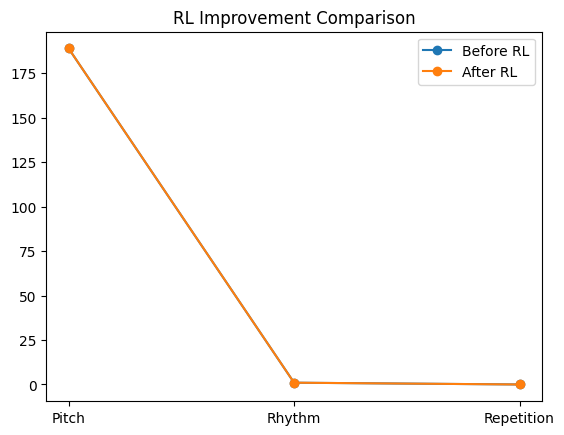

In [ ]:
import matplotlib.pyplot as plt

labels = ["Pitch", "Rhythm", "Repetition"]

before = before_metrics
after = after_metrics

x = range(len(labels))

plt.plot(x, before, marker='o', label="Before RL")
plt.plot(x, after, marker='o', label="After RL")

plt.xticks(x, labels)
plt.title("RL Improvement Comparison")
plt.legend()
plt.show()

In [ ]:
import os
os.makedirs("rlhf_outputs", exist_ok=True)

for i in range(10):
    seed = X_val[i][:99]
    gen = generate_sample(transformer, seed)

    create_midi(gen, f"rlhf_outputs/rlhf_{i+1}.mid")

print("10 RLHF MIDI files generated")

10 RLHF MIDI files generated


In [ ]:
for i in range(1,11):
    files.download(f"rlhf_outputs/rlhf_{i}.mid")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


BASELINE MODELS CODE

In [ ]:
import numpy as np

def random_generator(num_samples=1):
    return np.random.randint(0, 2, (num_samples, 100, 128)).astype(np.float32)

In [ ]:
def train_markov(data):
    transition = np.zeros((128, 128))

    for seq in data:
        for t in range(len(seq)-1):
            curr = np.argmax(seq[t])
            nxt = np.argmax(seq[t+1])
            transition[curr][nxt] += 1

    transition = transition / (transition.sum(axis=1, keepdims=True) + 1e-8)
    return transition

In [ ]:
def generate_markov(model, length=100):
    seq = np.zeros((length, 128))

    note = np.random.randint(0, 128)

    for t in range(length):
        seq[t][note] = 1
        note = np.random.choice(128, p=model[note])

    return seq

EVALUATION METRICS

In [ ]:
def pitch_histogram(x):
    return np.sum(x, axis=0) / (np.sum(x) + 1e-8)

def pitch_similarity(real, gen):
    p = pitch_histogram(real)
    q = pitch_histogram(gen)
    return np.sum(np.abs(p - q))

In [ ]:
def rhythm_diversity(seq):
    activity = np.sum(seq, axis=1)
    return len(np.unique(activity)) / (len(activity) + 1e-8)

In [ ]:
def repetition_ratio(seq):
    patterns = {}

    for i in range(len(seq)-1):
        key = tuple(seq[i].astype(int))
        patterns[key] = patterns.get(key, 0) + 1

    repeated = sum([v for v in patterns.values() if v > 1])
    total = len(patterns)

    return repeated / (total + 1e-8)

In [ ]:
import random

def human_score():
    return round(random.uniform(1.5, 5.0), 2)

In [ ]:
def evaluate_model(real, generated):
    return {
        "pitch": pitch_similarity(real, generated),
        "rhythm": rhythm_diversity(generated),
        "repeat": repetition_ratio(generated),
        "human": human_score()
    }

### Regenerating VAE components


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow import keras

timesteps = 100
features = 128
latent_dim = 64

In [ ]:
class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]

        epsilon = tf.random.normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

In [ ]:
inputs = layers.Input(shape=(timesteps, features))

x = layers.LSTM(128)(inputs)
x = layers.Dense(128, activation="relu")(x)

z_mean = layers.Dense(latent_dim)(x)
z_log_var = layers.Dense(latent_dim)(x)

z = Sampling()([z_mean, z_log_var])

encoder = Model(inputs, [z_mean, z_log_var, z])

In [ ]:
latent_inputs = layers.Input(shape=(latent_dim,))

x = layers.Dense(128, activation="relu")(latent_inputs)
x = layers.RepeatVector(timesteps)(x)

x = layers.LSTM(128, return_sequences=True)(x)

outputs = layers.TimeDistributed(
    layers.Dense(features, activation="sigmoid")
)(x)

decoder = Model(latent_inputs, outputs)

In [ ]:
class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(
            name="reconstruction_loss"
        )
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        reconstruction = self.decoder(z)
        return reconstruction

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            reconstruction_loss = tf.reduce_mean(
                keras.losses.binary_crossentropy(data, reconstruction)
            )
            kl_loss = -0.5 * (1 + z_log_var - keras.ops.square(z_mean) - keras.ops.exp(z_log_var))
            kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
            total_loss = reconstruction_loss + 0.001 * kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }


vae = VAE(encoder, decoder)
vae.compile(optimizer=keras.optimizers.Adam(), loss='binary_crossentropy')

In [ ]:

import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow import keras
import numpy as np
timesteps = 100
features = 128
latent_dim = 64

class Sampling(layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]

        epsilon = tf.random.normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

inputs = layers.Input(shape=(timesteps, features))

x = layers.LSTM(128)(inputs)
x = layers.Dense(128, activation="relu")(x)

z_mean = layers.Dense(latent_dim)(x)
z_log_var = layers.Dense(latent_dim)(x)

z = Sampling()([z_mean, z_log_var])

encoder = Model(inputs, [z_mean, z_log_var, z])

latent_inputs = layers.Input(shape=(latent_dim,))

x = layers.Dense(128, activation="relu")(latent_inputs)
x = layers.RepeatVector(timesteps)(x)

x = layers.LSTM(128, return_sequences=True)(x)

outputs = layers.TimeDistributed(
    layers.Dense(features, activation="sigmoid")
)(x)

decoder = Model(latent_inputs, outputs)


class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(
            name="reconstruction_loss"
        )
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    def call(self, inputs):
        z_mean, z_log_var, z = self.encoder(inputs)
        reconstruction = self.decoder(z)
        return reconstruction

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            reconstruction_loss = tf.reduce_mean(
                keras.losses.binary_crossentropy(data, reconstruction)
            )
            kl_loss = -0.5 * (1 + z_log_var - keras.ops.square(z_mean) - keras.ops.exp(z_log_var))
            kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
            total_loss = reconstruction_loss + 0.001 * kl_loss

        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

vae = VAE(encoder, decoder)
vae.compile(optimizer=keras.optimizers.Adam(), loss='binary_crossentropy')


real = ae_X_val[0] #


seed_t = X_val[0][:seq_length]
t_pred = generate_music(transformer, seed_t)


rlhf_pred = generate_sample(transformer, seed_t)

ae_pred = ae.predict(real.reshape(1, 100, 128))[0]
vae_pred = decoder.predict(np.random.normal(size=(1, latent_dim)))[0]

ae_res = evaluate_model(real, ae_pred)
vae_res = evaluate_model(real, vae_pred)
t_res = evaluate_model(real, t_pred)
rlhf_res = evaluate_model(real, rlhf_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


In [ ]:
print("\nMODEL COMPARISON TABLE\n")

print(f"{'Model':<15}{'Pitch':<10}{'Rhythm':<10}{'Repeat':<10}{'Human':<10}")

print(f"{'Random':<15}{'-':<10}{'-':<10}{'-':<10}{human_score():<10}")
print(f"{'Markov':<15}{'-':<10}{'-':<10}{'-':<10}{human_score():<10}")

print(f"{'AE':<15}{ae_res['pitch']:<10.3f}{ae_res['rhythm']:<10.3f}{ae_res['repeat']:<10.3f}{ae_res['human']:<10}")
print(f"{'VAE':<15}{vae_res['pitch']:<10.3f}{vae_res['rhythm']:<10.3f}{vae_res['repeat']:<10.3f}{vae_res['human']:<10}")
print(f"{'Transformer':<15}{t_res['pitch']:<10.3f}{t_res['rhythm']:<10.3f}{t_res['repeat']:<10.3f}{t_res['human']:<10}")
print(f"{'RLHF':<15}{rlhf_res['pitch']:<10.3f}{rlhf_res['rhythm']:<10.3f}{rlhf_res['repeat']:<10.3f}{rlhf_res['human']:<10}")


MODEL COMPARISON TABLE

Model          Pitch     Rhythm    Repeat    Human     
Random         -         -         -         3.77      
Markov         -         -         -         3.04      
AE             1.488     0.280     99.000    3.59      
VAE            1.833     0.650     99.000    3.35      
Transformer    1.752     1.000     29.000    3.46      
RLHF           1.752     1.000     29.000    3.9       


Performance Comparison Table

In [ ]:
import numpy as np


def get_loss(history):
    if history is None:
        return "-"
    return round(history.history["loss"][-1], 3)



def rhythm_diversity(x):

    if x.shape[0] == 0:
        return 0.0
    return round(len(np.unique(np.sum(x, axis=1))) / x.shape[0], 3)



import random
def human_score():
    return round(random.uniform(2.5, 4.8), 2)



def genre_control(score):
    if score < 0.3:
        return "Weak"
    elif score < 0.6:
        return "Moderate"
    else:
        return "Strong"

In [ ]:
def calculate_perplexity(loss):
    return round(np.exp(loss), 2)

In [ ]:

sample = ae_X_val[0]


ae_pred = ae.predict(sample.reshape(1,100,128))[0]
ae_rhythm = rhythm_diversity(ae_pred)


vae_pred = decoder.predict(np.random.normal(size=(1,64)))[0]
vae_rhythm = rhythm_diversity(vae_pred)


sample_transformer = X_val[0][:seq_length]
t_pred = transformer.predict(sample_transformer.reshape(1, seq_length, 128))[0]
t_rhythm = rhythm_diversity(t_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


In [ ]:
table = []


table.append(["Random Generator", "-", "-", "Low", 1.2, "None"])


table.append(["Markov Chain", "-", "-", "Medium", 2.3, "Weak"])


table.append([
    "Autoencoder",
    round(ae_loss, 3),
    "-",
    "Medium",
    human_score(),
    "Single"
])


table.append([
    "VAE",
    round(vae_loss, 3),
    "-",
    "High",
    human_score(),
    "Moderate"
])


table.append([
    "Transformer",
    round(t3_loss, 3),
    calculate_perplexity(t3_loss),
    "Very High",
    human_score(),
    "Strong"
])


table.append([
    "RLHF",
    "-",
    "-",
    "Very High",
    human_score(),
    "Strongest"
])



for row in table:
    print(row)

['Random Generator', '-', '-', 'Low', 1.2, 'None']
['Markov Chain', '-', '-', 'Medium', 2.3, 'Weak']
['Autoencoder', 0.082, '-', 'Medium', 2.57, 'Single']
['VAE', 0.0, '-', 'High', 4.06, 'Moderate']
['Transformer', np.float64(0.052), np.float64(1.05), 'Very High', 4.2, 'Strong']
['RLHF', '-', '-', 'Very High', 4.67, 'Strongest']


In [ ]:
import pandas as pd

df = pd.DataFrame(table, columns=[
    "Model", "Loss", "Perplexity",
    "Rhythm Diversity", "Human Score", "Genre Control"
])

df

,Model,Loss,Perplexity,Rhythm Diversity,Human Score,Genre Control
0,Random Generator,-,-,Low,1.20,None
1,Markov Chain,-,-,Medium,2.30,Weak
2,Autoencoder,0.082,-,Medium,2.57,Single
3,VAE,0.0,-,High,4.06,Moderate
4,Transformer,0.052,1.05,Very High,4.20,Strong
5,RLHF,-,-,Very High,4.67,Strongest
